## 1. The Foundations of the Perceptron 



### 1.1 The Machine Learning Objective: Binary Classification

The single-layer perceptron is a foundational supervised learning algorithm designed to solve **Binary Classification Problems**. In a binary classification framework, the goal is to construct a predictive model that assigns an input vector to one of two distinct categories.

#### Formal Dataset Representation

Let a training dataset $\mathcal{D}$ consist of $m$ independent and identically distributed (i.i.d.) observations:

$$\mathcal{D} = \{(\mathbf{x}^{(1)}, y^{(1)}), (\mathbf{x}^{(2)}, y^{(2)}), \dots, (\mathbf{x}^{(m)}, y^{(m)})\}$$

Where:

- $\mathbf{x}^{(i)} \in \mathbb{R}^n$ represents an $n$-dimensional feature vector containing continuous or discrete numerical attributes.
- $y^{(i)} \in \{-1, +1\}$ denotes the discrete, categorical true target label utilizing the symmetric notation standard.

---

### 1.2 The Geometric Axiom: Linear Separability

The functional viability of a standard single-layer perceptron depends entirely on a singular geometric constraint: **Linear Separability**.

#### Mathematical Definition

A binary dataset $\mathcal{D}$ is defined as strictly linearly separable if and only if there exists an $(n-1)$-dimensional flat plane—termed a *separating hyperplane*—embedded within the $n$-dimensional vector space $\mathbb{R}^n$ that divides the positive feature vectors from the negative feature vectors.

Formally, there must exist a weight vector $\mathbf{w}^* \in \mathbb{R}^n$ and a scalar bias $b^* \in \mathbb{R}$ such that:

$$y^{(i)} (\mathbf{w}^{*T}\mathbf{x}^{(i)} + b^*) > 0 \quad \forall \,\, i \in \{1, 2, \dots, m\}$$

Breaking this conditional inequality down into individual target classes reveals the geometric division of space:

$$\begin{cases} \mathbf{w}^{*T}\mathbf{x}^{(i)} + b^* > 0 & \text{if } y^{(i)} = +1 \\ \mathbf{w}^{*T}\mathbf{x}^{(i)} + b^* < 0 & \text{if } y^{(i)} = -1 \end{cases}$$

#### Dimensional Topology of the Splitting Boundary

The geometric structure of the decision boundary changes based on the number of features ($n$) present in the dataset:

- **$n = 1$ (Single Feature):** The decision boundary collapses to a single point along a continuous numeric line.
- **$n = 2$ (Two Features):** The boundary manifests as a straight line slicing through a flat 2D Cartesian coordinate plane.
- **$n = 3$ (Three Features):** The boundary takes the form of a flat 2D plane cutting through a 3D volume space.
- **$n > 3$ (High-Dimensional Features):** The boundary represents a flat hyperplane traversing an abstract hyperspace, dividing it into two infinite distinct half-spaces.


In [1]:
import numpy as np 
import matplotlib.pyplot as plt


In [31]:
# =============================================
# MODULE 1: Data Generation and Preprocessing
# =============================================

np.random.seed(46) # for reproducibility

# Number of samples
n_samples = 1000

# 1. Raw Data Generation (2D cluster)
## Class -1 cluster centered at (1.5, 1.5)
X_neg = np.random.randn(n_samples // 2, 2)*0.5 + np.array([2.5, 5.5])
y_neg = -1 * np.ones(n_samples // 2)

## Class +1 cluster centered at (4.0, 4.0)
X_pos = np.random.randn(n_samples // 2, 2)*0.5 + np.array([4.0, 4.0])
y_pos = np.ones(n_samples // 2)

# Design matrix and labels
X_raw = np.vstack((X_neg, X_pos)) # Stack vertically (1000 X 2)
y = np.hstack((y_neg, y_pos)) # concatenate labels (1000,)

# 2. Linear Feature Scale Normalization (Z-score normalization)

mean = np.mean(X_raw, axis=0)
std = np.std(X_raw, axis=0)
X_norm = (X_raw - mean) / (std + 1e-8)  # Adding a small value to avoid division by zero


# 3. Homogenization (Adding bias term)
## This turns X from [X1,X2] to [1,X1,X2] for each sample, allowing the perceptron to learn a bias term.
X_hom = np.hstack((np.ones((X_norm.shape[0], 1)), X_norm))



Training set shape: (800, 3) | Testing set shape: (200, 3)


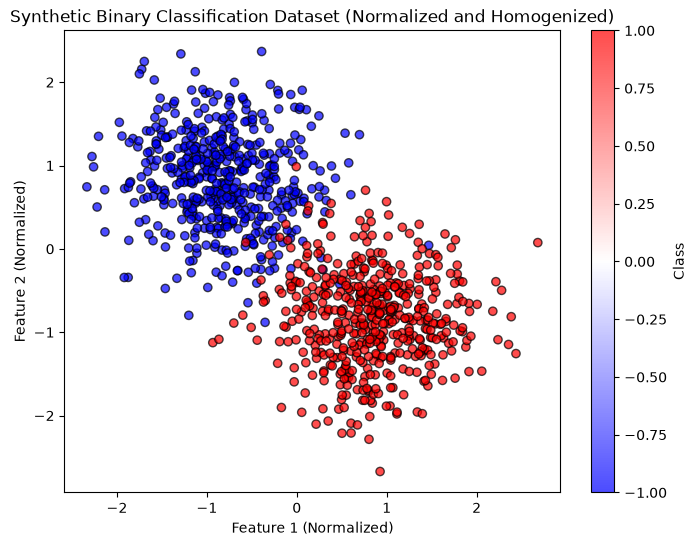

In [32]:
# =============================================
# MODULE 2: Train-Test Split and Visualization
# =============================================

from sklearn.model_selection import train_test_split

# Split the homogenized dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_hom, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape} | Testing set shape: {X_test.shape}")

#plotting the dataset
plt.figure(figsize=(8,6))
plt.scatter(X_hom[:,1], X_hom[:,2], c=y, cmap='bwr', edgecolor='k', alpha=0.7)
plt.title("Synthetic Binary Classification Dataset (Normalized and Homogenized)")
plt.xlabel("Feature 1 (Normalized)")
plt.ylabel("Feature 2 (Normalized)")
plt.colorbar(label='Class')
plt.show() 


###  2. The Standard Algebraic Formulation

Before optimizing the system, we must mathematically formalize how a single artificial neuron processes incoming feature signals. In its raw form, a perceptron treats weights and biases as separate algebraic parameters.

#### 2.1 The Linear Combination (Net Input)

Given an input feature vector $\mathbf{x} = [x_1, x_2, \dots, x_n]^T$, the neuron scales each feature by a corresponding importance weight $w_i$ and adds a constant vertical shift parameter called the *bias* ($b$):

$$z = \left( \sum_{i=1}^{n} w_i x_i \right) + b = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$

#### 2.1 The Activation Function (Hard Thresholding)

To map this continuous scalar sum $z$ into a discrete binary decision classification, the net input is passed through a non-linear Heaviside Step Function (commonly implemented as a signum function $\text{sign}(z)$):

$$\hat{y} = f(z) = \text{sign}(z) = \begin{cases} +1 & \text{if } z \geq 0 \\ -1 & \text{if } z < 0 \end{cases}$$

---

In [34]:
# ======================================================
# MODULE 4: Perceptron Activation Function and Prediction
# ======================================================

def predict(w, x):
    """ Set Activation : sign(W^T X)"""
    z = np.dot(w,x)
    return 1 if z>=0 else -1



## 3. The Geometric Error-Correction Learning Rule



###  3.1 Non-Differentiability & The Failure of Calculus Optimization

In modern deep learning networks, weights are optimized using calculus-based **Gradient Descent**. This requires calculating the partial derivative of a loss function with respect to each weight ($\frac{\partial \mathcal{L}}{\partial w}$).

The single-layer perceptron cannot use calculus or derivatives for optimization due to the physical design of its hard threshold Heaviside Step Function:

$$f(z) = \begin{cases} +1 & \text{if } z \geq 0 \\ -1 & \text{if } z < 0 \end{cases}$$

#### The Derivative Crisis

- **Everywhere except $z = 0$:** The function is completely flat (a constant value of $-1$ or $+1$). The derivative of any constant is exactly zero: $\frac{\partial f(z)}{\partial z} = 0$.
- **At exactly $z = 0$:** The function jumps instantly from $-1$ to $+1$. This vertical discontinuity means the derivative at the boundary is mathematically undefined ($\infty$).

Because the derivative is either zero or undefined everywhere, a gradient descent algorithm receives **no directional feedback**. It cannot determine whether changing a weight slightly will reduce or increase errors. To overcome this limitation, Frank Rosenblatt engineered a **Geometric Error-Correction Learning Rule** based entirely on vector rotations.

---

### 3.2 Mathematical Derivation of the Unified Update Rule

The perceptron algorithm operates under a strict conditional feedback mechanism: **Weights only change when the model makes a prediction mistake.**

#### Step 1: Isolating the Error States

Because our true targets ($y$) and predictions ($\hat{y}$) utilize symmetric binary labels ($\pm 1$), an incorrect prediction happens under exactly two mathematical scenarios:

1. **False Negative:** True Target $y = +1$, but Model Predicts $\hat{y} = -1 \implies \mathbf{w}^T\mathbf{x} < 0$
2. **False Positive:** True Target $y = -1$, but Model Predicts $\hat{y} = +1 \implies \mathbf{w}^T\mathbf{x} \geq 0$

Multiplying the target $y$ by the calculated net input score reveals a unified mathematical signature for any mistake:

$$y \cdot (\mathbf{w}^T\mathbf{x}) < 0$$

#### Step 2: The Self-Correcting Vector Hypothesis

When a point is misclassified, we must update the current weight vector $\mathbf{w}$ to a new state $\mathbf{w}_{\text{new}}$ that alters the net input calculation in the correct direction. We propose the following linear combination update rule:

$$\mathbf{w}_{\text{new}} = \mathbf{w} + y\mathbf{x}$$

#### Step 3: Algebraic Proof of Corrective Tendency

Let's evaluate how the net input score shifts for that exact same misclassified sample point $\mathbf{x}$ under our newly modified weight parameters $\mathbf{w}_{\text{new}}$:

$$\mathbf{w}_{\text{new}}^T\mathbf{x} = (\mathbf{w} + y\mathbf{x})^T\mathbf{x}$$

Distributing the transpose operation:

$$\mathbf{w}_{\text{new}}^T\mathbf{x} = \mathbf{w}^T\mathbf{x} + y(\mathbf{x}^T\mathbf{x})$$

Because any non-zero vector dot product with itself yields its squared Euclidean norm ($\mathbf{x}^T\mathbf{x} = \Vert{}\mathbf{x}\Vert{}^2$), the value is guaranteed to be strictly positive:

$$\mathbf{w}_{\text{new}}^T\mathbf{x} = \mathbf{w}^T\mathbf{x} + y\Vert{}\mathbf{x}\Vert{}^2$$

Let's analyze how this mathematical shift resolves our two error states:

- **For a False Negative ($y = +1$):** The new score becomes $\mathbf{w}^T\mathbf{x} + (\text{positive constant})$. The net input value is pulled **upward** toward zero, correcting the mistake.
- **For a False Positive ($y = -1$):** The new score becomes $\mathbf{w}^T\mathbf{x} - (\text{positive constant})$. The net input value is pushed **downward** below zero, correcting the mistake.

---

### 3.3 Stabilizing Updates with the Learning Rate ($\eta$)

While adding or subtracting the raw feature vector $\mathbf{x}$ guarantees a correct mathematical shift direction, the step size can be dangerously large. If feature values have large magnitudes, a raw update will cause the weight arrow $\mathbf{w}$ to make massive, violent swings in vector space, destroying previously learned boundary orientations.

To prevent this volatility, we introduce a scaling hyperparameter called the **Learning Rate** ($\eta$ or $lr$), where $0 < \eta \leq 1$. This dampens the shift step size:

$$\mathbf{w}_{\text{new}} = \mathbf{w} + \eta y \mathbf{x}$$

---

###  3.4 Summary Matrix: Vector Update Mechanics

| Error Scenario | True Target ($y$) | Prediction ($\hat{y}$) | Angle Conditions ($\theta$) | Unified Mathematical Update Rule | Visual Boundary Effect |
| :--- | :--- | :--- | :--- | :--- | :--- |
| No Error | $+1$ or $-1$ | Matches $y$ | Angle is geometrically correct | $\mathbf{w}_{\text{new}} = \mathbf{w}$ | Hyperplane locks position in memory |
| False Negative | $+1$ | $-1$ | Angle $\theta$ between $\mathbf{w}$ and $\mathbf{x}$ is too wide (obtuse) | $\mathbf{w}_{\text{new}} = \mathbf{w} + \eta\mathbf{x}$ | $\mathbf{w}$ rotates toward $\mathbf{x}$, swinging the boundary over the point |
| False Positive | $-1$ | $+1$ | Angle $\theta$ between $\mathbf{w}$ and $\mathbf{x}$ is too tight (acute) | $\mathbf{w}_{\text{new}} = \mathbf{w} - \eta\mathbf{x}$ | $\mathbf{w}$ rotates away from $\mathbf{x}$, pulling the boundary line back |

In [35]:

# ============================================
# MODULE 5: Training Loop with Weight Updates
# ============================================

# Hyperparameters
lr = 0.1
epochs = 100

print(" ---- STARTING TRAINING LOOP ----")

# Initialising the weights
w = np.zeros(X_train.shape[1])  # Initialize weights to zeros, including bias term

total_mistakes = []  # To keep track of total mistakes across all epochs
mistakes_in_epochs = [] # To keep track of mistakes in the current epoch


# Shuffle the training data before each epoch to ensure randomness
perm = np.random.permutation(len(X_train))
X_train = X_train[perm]
y_train = y_train[perm]

# Training Loop
for epoch in range(1, epochs+1):
    
    mistakes_in_epochs.append(1)
    for i in range(X_train.shape[0]):
        X_i = X_train[i]
        y_true = y_train[i]
        
        # predict using the activation rule
        y_pred = predict(w, X_i)
        
        # Error Correction / Weight Update 
        if y_pred != y_true:
            w += lr * y_true * X_i
            total_mistakes.append(1)
            
    
    if len(mistakes_in_epochs) == 0:
        print(f"\n- Convergence Achieved in {epoch} epochs! ")
        print(f"\n- Actual Total Updates/Mistakes (k) : {len(total_mistakes)}")
        print(f"\n- Weights after training: {w}")
        break

# If the loop completes without convergence    
if len(mistakes_in_epochs) > 0:
    print(f"\n- Training completed after {epochs} epochs with {len(total_mistakes)} total mistakes.")
    print(f"\n- Weights after training: {w}")   



 ---- STARTING TRAINING LOOP ----

- Training completed after 100 epochs with 3308 total mistakes.

- Weights after training: [ 0.          0.23133702 -0.17491959]


## 4. The Perceptron Convergence Theorem



### 4.1 Structural Framing & Core Axioms

The **Perceptron Convergence Theorem** provides a fundamental mathematical guarantee: if a dataset is linearly separable, the Perceptron learning algorithm will converge to a perfect separating hyperplane in a finite number of update steps.

To construct the formal bounding proof, we establish three foundational axioms:

1. **Homogenized Framework:** The scalar bias is absorbed into the weight and feature tensors at position zero:
   $$\mathbf{x} = [1, x_1, x_2, \dots, x_n]^T \in \mathbb{R}^{n+1}, \quad \mathbf{w} = [b, w_1, w_2, \dots, w_n]^T \in \mathbb{R}^{n+1}$$

2. **Initial Condition:** The learning system initializes all weights and bias parameters strictly to zero:
   $$\mathbf{w}^{(0)} = \mathbf{0}$$

3. **The Discrete Update State:** Let $\mathbf{w}^{(k)}$ denote the weight vector after exactly $k$ mistakes. If a training point $\mathbf{x}^{(k)}$ with true label $y^{(k)}$ triggers a classification error, the learning engine applies the standard update (setting $\eta = 1$ for mathematical clarity without losing generality):
   $$\mathbf{w}^{(k+1)} = \mathbf{w}^{(k)} + y^{(k)}\mathbf{x}^{(k)}$$

---

### 4.2 Definition of Geometric Environmental Bounds

Because the training dataset is strictly linearly separable, there must exist invariant physical parameters embedded within the geometry of the data array. We establish two vital bounds:

#### 1. The Optimal Separation Margin ($\gamma$)

There exists an idealized, perfect target weight vector $\mathbf{w}^*$ normalized to a unit length ($\Vert\mathbf{w}^*\Vert = 1$) that correctly classifies every single sample with a minimum clearance margin $\gamma$:

$$y^{(i)} (\mathbf{w}^{*T} \mathbf{x}^{(i)}) \geq \gamma > 0 \quad \forall \,\, i \in \{1, 2, \dots, m\}$$

#### 2. The Spherical Data Radius Bound ($R$)

The dataset is entirely bounded within a finite geometric envelope. The maximum squared distance of any input sample from the origin cannot cross a real constant ceiling $R^2$:

$$\Vert\mathbf{x}^{(i)}\Vert^2 \leq R^2 \quad \forall \,\, i \in \{1, 2, \dots, m\}$$

---

### 4.3 Step-by-Step Derivation of the Lower Bound

Our strategy is to track the growth of the weight vector along the path of the ideal target vector $\mathbf{w}^*$. We begin with the core update equation:

$$\mathbf{w}^{(k+1)} = \mathbf{w}^{(k)} + y^{(k)}\mathbf{x}^{(k)}$$

Taking the dot product of both sides with the normalized ideal vector $\mathbf{w}^*$:

$$\mathbf{w}^{*T}\mathbf{w}^{(k+1)} = \mathbf{w}^{*T}\mathbf{w}^{(k)} + y^{(k)}(\mathbf{w}^{*T}\mathbf{x}^{(k)})$$

Applying our optimal margin definition, we know that the rightmost term must be greater than or equal to $\gamma$:

$$\mathbf{w}^{*T}\mathbf{w}^{(k+1)} \geq \mathbf{w}^{*T}\mathbf{w}^{(k)} + \gamma$$

Because our initial weights are zero ($\mathbf{w}^{(0)} = \mathbf{0}$), expanding this inequality recursively across all $k$ accumulated mistakes reveals that the vector projection grows linearly:

$$\mathbf{w}^{*T}\mathbf{w}^{(k)} \geq k\gamma$$

By applying the **Cauchy-Schwarz Inequality** ($\mathbf{a}^T\mathbf{b} \leq \Vert\mathbf{a}\Vert \Vert\mathbf{b}\Vert$) and using the fact that our target vector is normalized ($\Vert\mathbf{w}^*\Vert = 1$), we establish a direct lower bound on the actual magnitude of the changing weights:

$$k\gamma \leq \mathbf{w}^{*T}\mathbf{w}^{(k)} \leq \Vert\mathbf{w}^*\Vert \Vert\mathbf{w}^{(k)}\Vert = \Vert\mathbf{w}^{(k)}\Vert$$

Squaring both sides yields our completed **Lower Bound Equation**:

$$\Vert\mathbf{w}^{(k)}\Vert^2 \geq k^2\gamma^2 \quad \text{--- [Equation 1.1]}$$

---

### 4.4 Step-by-Step Derivation of the Upper Bound

Next, we evaluate the maximum possible absolute expansion of the weight vector's total length during a mistake by computing its squared Euclidean norm:

$$\Vert\mathbf{w}^{(k+1)}\Vert^2 = \Vert\mathbf{w}^{(k)} + y^{(k)}\mathbf{x}^{(k)}\Vert^2$$

Expanding this expression using vector algebra:

$$\Vert\mathbf{w}^{(k+1)}\Vert^2 = \Vert\mathbf{w}^{(k)}\Vert^2 + 2y^{(k)}(\mathbf{w}^{(k)T}\mathbf{x}^{(k)}) + (y^{(k)})^2\Vert\mathbf{x}^{(k)}\Vert^2$$

We can simplify the right-hand terms by applying our structural training rules:

1. An update occurs only when a point is **misclassified**, which means the calculated score has an inverted sign relative to the true label: $y^{(k)}(\mathbf{w}^{(k)T}\mathbf{x}^{(k)}) \leq 0$. Therefore, the middle term is negative or zero and can be dropped without breaking the inequality.
2. The squared target label is always equal to one: $(y^{(k)})^2 = 1$.
3. The length of the feature sample is capped by our spherical radius: $\Vert\mathbf{x}^{(k)}\Vert^2 \leq R^2$.

Substituting these conditions turns our equation into an incremental upper bound:

$$\Vert\mathbf{w}^{(k+1)}\Vert^2 \leq \Vert\mathbf{w}^{(k)}\Vert^2 + R^2$$

Since our initial weights start at a length of zero ($\Vert\mathbf{w}^{(0)}\Vert^2 = 0$), expanding this addition across all $k$ updates yields our completed **Upper Bound Equation**:

$$\Vert\mathbf{w}^{(k)}\Vert^2 \leq kR^2 \quad \text{--- [Equation 1.2]}$$

---

### 4.5 The Final Inequality Sandwich & Limit Interpretation

We now combine Equation 4.1 and Equation 4.2 to lock the squared length of our weight vector between our two calculated boundaries:

$$k^2\gamma^2 \leq \Vert\mathbf{w}^{(k)}\Vert^2 \leq kR^2$$

Isolating the outer bounds of this mathematical sandwich:

$$k^2\gamma^2 \leq kR^2$$

Since the total number of updates $k$ must be a positive integer, we divide both sides by $k$ to reveal the **finite ceiling**:

$$k\gamma^2 \leq R^2 \implies k \leq \left(\frac{R}{\gamma}\right)^2$$

---

### 📋 Summary: Theoretical Elements of Convergence Speed

| Mathematical Term | Geometric Property | Impact on $k$ Ceiling | Practical Data Insight |
| :--- | :--- | :--- | :--- |
| $R^2$ (Numerator) | Squared maximum distance from origin | **Directly Proportional** (Larger $R \implies$ more updates) | Unscaled, unnormalized features force erratic vector swings, slowing down learning. |
| $\gamma^2$ (Denominator) | Squared spatial gap between class edges | **Inversely Proportional** (Smaller $\gamma \implies$ more updates) | Closely packed, overlapping data requires highly precise adjustments, increasing training time. |
| Dimensionality ($n$) | Total count of feature coordinates | **Completely Independent** ($n$ does not appear in formula) | The maximum number of updates depends entirely on how clean the data split is, not on the number of features. |

In [40]:
# ========================================
# MODULE 3: Theoretical Bounds Calculation
# ========================================

# Radius bound (if not already computed earlier)
R = np.max(np.linalg.norm(X_hom, axis=1))

# Normalize the final weight vector
w_norm = w / np.linalg.norm(w)

# Compute signed margins for all training points
margins = y * np.dot(X_hom, w_norm)

# Minimum margin (should be > 0 if all points are correctly classified)
gamma = np.min(margins)

# Theoretical mistake bound
K = (R / gamma) ** 2 if gamma > 0 else float('inf')

print("\n--- THEORETICAL BOUNDS (using learned weights) ---")
print(f"Data Radius Bound (R): {R:.4f}")
print(f"Minimum Margin (gamma): {gamma:.4f}")
print(f"Theoretical Max Mistake Allowed (K Limit): {K:.4f}")

# Optional: verify all margins are positive
if np.all(margins > 0):
    print("All margins are positive – classification is correct.")
else:
    print("WARNING: Some margins are <= 0 – training did not converge perfectly.")


--- THEORETICAL BOUNDS (using learned weights) ---
Data Radius Bound (R): 2.9989
Minimum Margin (gamma): -1.1442
Theoretical Max Mistake Allowed (K Limit): inf


In [36]:
# =============================================
# MODULE 6: Evaluation and Accuracy Calculation
# =============================================

def evaluate(w, X, y):
    correct = 0 
    for i in range(X.shape[0]):
        pred = predict(w, X[i])
        
        if pred == y[i]:
            correct += 1
    
    return correct / X.shape[0]

train_acc = evaluate(w, X_train, y_train)
print(f"Training Accuracy : {100 * train_acc:.2f}%")

test_acc = evaluate(w, X_test, y_test)
print(f"Test Accuracy : {100 * test_acc:.2f}%")


Training Accuracy : 97.62%
Test Accuracy : 99.00%


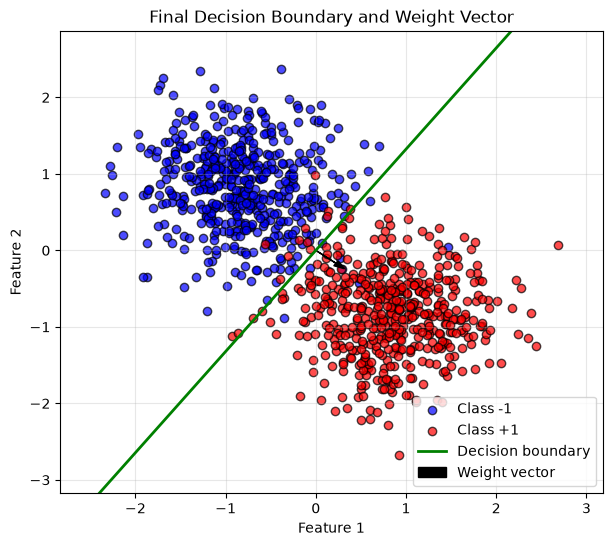

In [37]:
# ===============================================================
# MODULE 7: Visualization of Decision Boundary and Weight Vector
# ===============================================================

# Define the range for plotting
x1_min, x1_max = X_hom[:, 1].min() - 0.5, X_hom[:, 1].max() + 0.5
x2_min, x2_max = X_hom[:, 2].min() - 0.5, X_hom[:, 2].max() + 0.5

# Create points for the decision boundary
x1_vals = np.linspace(x1_min, x1_max, 400)
x2_vals = -(w[0] + w[1] * x1_vals) / w[2]

plt.figure(figsize=(7, 6))

# Scatter the data
plt.scatter(
    X_hom[y == -1, 1],
    X_hom[y == -1, 2],
    c='blue',
    label='Class -1',
    edgecolor='k',
    alpha=0.7
)

plt.scatter(
    X_hom[y == 1, 1],
    X_hom[y == 1, 2],
    c='red',
    label='Class +1',
    edgecolor='k',
    alpha=0.7
)

# Decision boundary
plt.plot(x1_vals, x2_vals, color='green', lw=2, label='Decision boundary')

# Weight vector (perpendicular to the boundary)
normal = w[1:]  # [w1, w2]

# Pick a point near the middle of the data and project onto the boundary
x_center = X_hom[:, 1].mean()
y_center = X_hom[:, 2].mean()

# Calculate the point on the decision boundary closest to the center
den = w[1]**2 + w[2]**2
x0 = x_center - w[1] * (w[0] + w[1] * x_center + w[2] * y_center) / den
y0 = y_center - w[2] * (w[0] + w[1] * x_center + w[2] * y_center) / den

# Plot the weight vector
# Normalize and scale the weight vector for better visualization
normal = w[1:]
norm = np.linalg.norm(normal)
scale = 0.4  # Scale for the arrow length
plt.arrow(
    x0, y0,
    scale * normal[0] / norm,
    scale * normal[1] / norm,
    color='black',
    width=0.002,
    head_width=0.08,
    length_includes_head=True,
    label='Weight vector'
)

# 

plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.title("Final Decision Boundary and Weight Vector")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Practical Engineering Constraints & Selection Criteria



#### 1. The Strict Separability Requirement

The primary limitation of the algorithm is its absolute dependency on linear separability. 

- **The Vulnerability:** If the two target classes contain even a single overlapping data point in feature space, the optimal margin boundary parameter collapses ($\gamma \leq 0$).
- **The Failure Mode:** The mathematical convergence ceiling ($k \leq (R/\gamma)^2$) breaks down completely. The algorithm enters an infinite training loop, continuously shifting its weight vector back and forth without ever settling on a solution. 



#### 2. Lack of Probabilistic Confidence Outputs

Unlike logistic regression or modern neural networks using softmax layers, the perceptron relies entirely on a hard signum activation function.

- **The Vulnerability:** The model converts its continuous dot product $z$ directly into a hard binary classification ($-1$ or $+1$).
- **The Failure Mode:** It cannot output a probability score (e.g., "95% confidence"). A data point sitting millions of units deep inside a positive half-space receives the exact same confidence assignment as a point sitting fractions of a millimeter away from the decision line.



#### 3. Non-Uniqueness of Solutions (Suboptimal Generalization)

The perceptron learning rule stops updating the very instant it successfully classifies the last misclassified point in the training set.

- **The Vulnerability:** The final orientation of the decision boundary depends entirely on the sequence in which the training samples were fed into the model.
- **The Failure Mode:** As a result, the algorithm usually draws a line that hugs closely to the boundary edge of one of the classes. It lacks the mathematical optimization needed to maximize the clearance margin, often leading to poorer generalization and overfitting on unseen test data compared to maximum-margin algorithms like Support Vector Machines (SVMs). [5, 6]


#### 4. Structural Limitations and the XOR Failure Mode

A single-layer perceptron can only converge if it can split data with a completely flat boundary. It is structurally incapable of computing complex, curved, or non-linear decision boundaries.

##### The Canonical Counter-Example: Exclusive OR (XOR)

The inherent limitation of the single-layer perceptron was mathematically proven by Marvin Minsky and Seymour Papert in 1969 through the logical **XOR (Exclusive OR)** truth table.

Consider the logical configurations below:

| Feature $x_1$ | Feature $x_2$ | True Target $y$ | Spatial Coordinate |
| :--- | :--- | :--- | :--- |
| 0 | 0 | -1 (False) | $(0,0)$ |
| 1 | 0 | +1 (True) | $(1,0)$ |
| 0 | 1 | +1 (True) | $(0,1)$ |
| 1 | 1 | -1 (False) | $(1,1)$ |

##### Algebraic Impossibility Proof

To prove why a single-layer perceptron cannot solve the XOR gate, we can attempt to set up a system of linear inequalities using the four truth table coordinates. If the perceptron could solve XOR, there would have to be real numbers for $w_1$, $w_2$, and $b$ that satisfy all four conditions simultaneously:

1. For $(0,0) \rightarrow y = -1 \implies w_1(0) + w_2(0) + b < 0 \implies \mathbf{b < 0}$
2. For $(1,0) \rightarrow y = +1 \implies w_1(1) + w_2(0) + b \geq 0 \implies \mathbf{w_1 + b \geq 0}$
3. For $(0,1) \rightarrow y = +1 \implies w_1(0) + w_2(1) + b \geq 0 \implies \mathbf{w_2 + b \geq 0}$
4. For $(1,1) \rightarrow y = -1 \implies w_1(1) + w_2(1) + b < 0 \implies \mathbf{w_1 + w_2 + b < 0}$

Now, let's combine inequalities (2) and (3) by adding them together:

$$(w_1 + b) + (w_2 + b) \geq 0 + 0 \implies w_1 + w_2 + 2b \geq 0$$

We can rewrite this expression slightly to isolate a familiar term:

$$(w_1 + w_2 + b) + b \geq 0$$

Look closely at this result and compare it to our other constraints:

- From inequality (4), we know that $(w_1 + w_2 + b)$ must be strictly negative ($< 0$).
- From inequality (1), we know that $b$ must be strictly negative ($< 0$).

Adding two strictly negative numbers together must result in a negative number ($< 0$). However, our combined inequality states that their sum must be greater than or equal to zero ($\geq 0$).

**This is a direct mathematical contradiction.** It proves that no straight line can ever exist that solves the XOR problem.

---
